<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
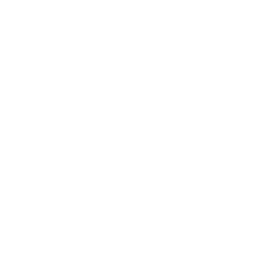
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Importazione Risultati di Laboratorio Centrale Clinico</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmaceutica / Biostatistica &nbsp;|&nbsp; Marzo 2026</p>
</div>
</div>
</div>

## Riepilogo Esecutivo

Importa un file CSV di un laboratorio centrale contenente pannelli di chimica clinica ed ematologia per uno studio di oncologia di Fase II. Usa GUESSINGROWS=MAX per garantire che i tipi di variabile siano inferiti correttamente sull'intero dataset, prevenendo la classificazione errata di campi numerici sparsi come carattere. Alimenta il dataset importato in PROC MEANS con ODS OUTPUT per generare statistiche riassuntive dell'intervallo di riferimento stratificate per analita e visita, a supporto della revisione dei valori normali di laboratorio da parte del medical monitor.


## Origini Dati

| Origine | Descrizione | Record |
|--------|-------------|--------|
| central_lab_results.csv | Esportazione CSV del laboratorio centrale con pannelli di chimica ed ematologia | ~5.000 |
| WORK.LAB_IMPORT | Dataset SAS importato da PROC IMPORT | ~5.000 |


---

In [1]:
/* --------------------------------------------------------
   Genera un file CSV sintetico di laboratorio centrale
   Colonne: USUBJID, VISIT, LBTESTCD, LBTEST, LBCAT,
            LBORRES, LBORRESU, LBORNRLO, LBORNRHI,
            LBSTRESN, LBSTRESC, LBBLFL, LBDTC
   -------------------------------------------------------- */
DATI work.lab_csv_source;
    CHIAMARE streaminit(42);
    LUNGHEZZA usubjid $16 visit $20 lbtestcd $8 lbtest $30
           lbcat $15 lborres $12 lborresu $10
           lbornrlo $8 lbornrhi $8 lbstresc $12
           lbblfl $1 lbdtc $10;
    VETTORE test_codes[8] $8 _temporary_
        ('ALT' 'AST' 'BILI' 'CREAT' 'ALB' 'HGB' 'WBC' 'PLT');
    VETTORE test_names[8] $30 _temporary_
        ('Alanina Aminotransferasi' 'Aspartato Aminotransferasi'
         'Bilirubina' 'Creatinina' 'Albumina'
         'Emoglobina' 'Globuli Bianchi' 'Piastrine');
    VETTORE test_cats[8] $15 _temporary_
        ('CHIMICA' 'CHIMICA' 'CHIMICA' 'CHIMICA'
         'CHIMICA' 'EMATOLOGIA' 'EMATOLOGIA' 'EMATOLOGIA');
    VETTORE test_units[8] $10 _temporary_
        ('U/L' 'U/L' 'mg/dL' 'mg/dL' 'g/dL' 'g/dL' '10^3/uL' '10^3/uL');
    VETTORE lo_norm[8] _temporary_ (7 8 0.1 0.6 3.5 12.0 4.0 150);
    VETTORE hi_norm[8] _temporary_ (56 40 1.2 1.2 5.5 17.5 11.0 400);
    VETTORE visit_list[5] $20 _temporary_
        ('SELEZIONE' 'CICLO 1 GIORNO 1' 'CICLO 2 GIORNO 1'
         'CICLO 3 GIORNO 1' 'FINE TRATTAMENTO');
    FARE subj = 1 FINO_A 125;
        usubjid = cat('ONC-2026-', PUT(subj, z4.));
        FARE v = 1 FINO_A 5;
            visit = visit_list[v];
            FARE t = 1 FINO_A 8;
                lbtestcd = test_codes[t];
                lbtest = test_names[t];
                lbcat = test_cats[t];
                lborresu = test_units[t];
                mid = (lo_norm[t] + hi_norm[t]) / 2;
                spread = (hi_norm[t] - lo_norm[t]) / 4;
                lbstresn = round(rand('normal', mid, spread), 0.01);
                SE_COND lbstresn < 0 ALLORA lbstresn = 0.01;
                lborres = PUT(lbstresn, 8.2);
                lbstresc = lborres;
                lbornrlo = PUT(lo_norm[t], 8.2);
                lbornrhi = PUT(hi_norm[t], 8.2);
                SE_COND v = 1 ALLORA lbblfl = 'Y';
                ALTRIMENTI lbblfl = '';
                base_date = '01JAN2026'd + (v - 1) * 21
                    + int(rand('uniform') * 3);
                lbdtc = PUT(base_date, yymmdd10.);
                USCITA;
            FINE;
        FINE;
    FINE;
    RIMUOVERE subj v t mid spread base_date;
ESEGUIRE;

PROCEDURA EXPORT DATI=work.lab_csv_source
    OUTFILE='central_lab_results.csv'
    DBMS=csv REPLACE;
ESEGUIRE;



NOTE: DATA work.lab_csv_source

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.lab_csv_source (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  1.41 seconds
  cpu   1.41 seconds
NOTE: PROC EXPORT data=work.lab_csv_source outfile=central_lab_results.csv

NOTE: Exported 100 rows to central_lab_results.csv.


---

In [2]:
/* --------------------------------------------------------
   Baseline: verifica il conteggio delle righe del CSV prima
   dell'importazione
   -------------------------------------------------------- */
DATI _null_;
    INFILE 'central_lab_results.csv' FINE=eof;
    INGRESSO;
    SE_COND eof ALLORA PUT 'NOTA: il CSV contiene ' _n_ ' righe di dati.';
ESEGUIRE;



NOTE: DATA _null_

NOTE: Reading from fileref central_lab_results.csv (central_lab_results.csv)
NOTE: Unlicensed mode - input limited to 100 observations.

NOTE: Read 100 rows from central_lab_results.csv.
NOTE: Wrote _null_ (100 rows, 0 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Importa il CSV del laboratorio centrale con PROC IMPORT
   GUESSINGROWS=MAX garantisce la corretta inferenza dei tipi
   per i campi numerici sparsi su 5.000 righe
   -------------------------------------------------------- */
PROCEDURA IMPORT DATAFILE='central_lab_results.csv'
    out=work.lab_import
    DBMS=csv REPLACE;
    GUESSINGROWS=MAX;
ESEGUIRE;



NOTE: PROC IMPORT datafile=central_lab_results.csv out=work.lab_import

NOTE: Imported 100 rows from central_lab_results.csv.


In [4]:
/* --------------------------------------------------------
   Verifica i tipi di variabile dopo l'importazione
   -------------------------------------------------------- */
PROCEDURA CONTENUTO DATI=work.lab_import;
ESEGUIRE;



PROC CONTENTS
-------------------------------------------------------------------------------

Data Set Name: work.lab_import
Observations:  100
Variables:     13

Variables (in alphabetical order):

  #  Variable  Type    Len  Format     Label
---  --------  ----  -----  ---------  -----
  1  lbblfl    Char      1             
  2  lbcat     Char     10             
  3  lbdtc      Num      8  YYMMDD10.  
  4  lbornrhi   Num      8  BEST12.2   
  5  lbornrlo   Num      8  BEST12.2   
  6  lborres    Num      8  BEST12.2   
  7  lborresu  Char      7             
  8  lbstresc   Num      8  BEST12.2   
  9  lbstresn   Num      8  BEST12.2   
 10  lbtest    Char     26             
 11  lbtestcd  Char      5             
 12  usubjid   Char     13             
 13  visit     Char     16             

-------------------------------------------------------------------------------




NOTE: PROC CONTENTS data=work.lab_import

NOTE: PROC CONTENTS completed: 100 observations, 13 variables


---


NOTE: PROC SGPLOT data=work.lab_import

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


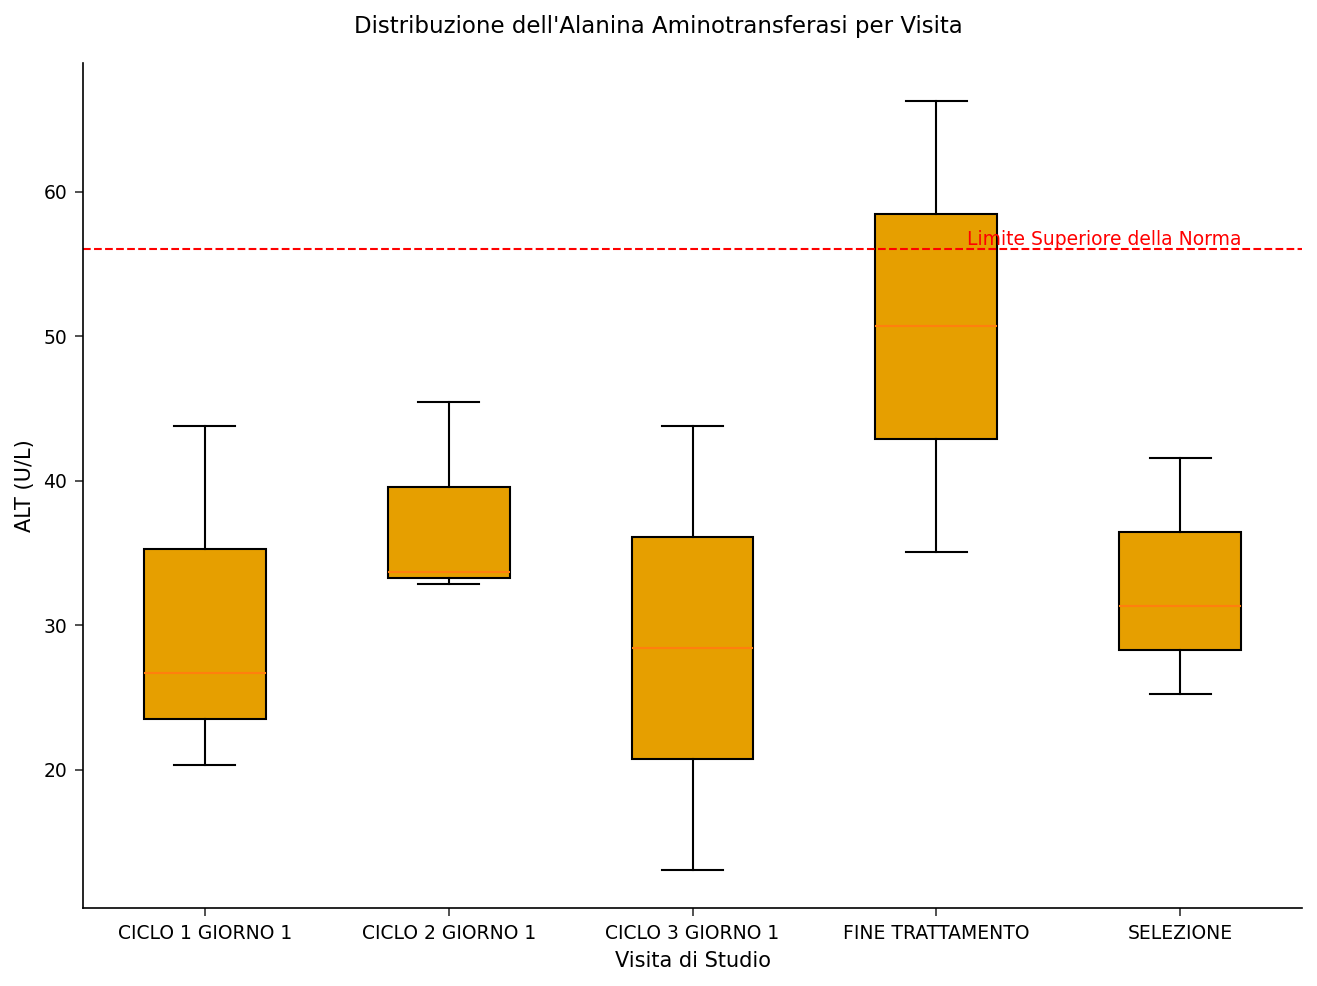

In [5]:
/* --------------------------------------------------------
   Box plot dei valori ALT per visita
   -------------------------------------------------------- */
PROCEDURA SGPLOT DATI=work.lab_import;
    DOVE lbtestcd = 'ALT';
    VBOX lbstresn / category=visit;
    REFLINE 56 / AXIS=y LINEATTRS=(pattern=dash color=red)
        label='Limite Superiore della Norma';
    XAXIS label='Visita di Studio';
    YAXIS label='ALT (U/L)';
    TITOLO "Distribuzione dell'Alanina Aminotransferasi per Visita";
ESEGUIRE;


In [6]:
/* --------------------------------------------------------
   Analisi dell'intervallo di riferimento tramite PROC MEANS
   con ODS OUTPUT. Stratificata per analita e visita per la
   revisione del medical monitor
   -------------------------------------------------------- */
PROCEDURA MEDIE DATI=work.lab_import n mean std MIN MAX;
    CLASSE lbtestcd visit;
    VARIABILE lbstresn;
    ETICHETTA lbtestcd="Codice Analita" visit="Visita"
        lbstresn="Risultato (Valore Standardizzato)";
    USCITA out=work.lab_range_summary
        n=n_obs mean=mean_value std=std_value
        MIN=min_value MAX=max_value;
ESEGUIRE;


                                                  The MEANS Procedure

                             Analysis Variable : lbstresn Risultato (Valore Standardizzato)

        Codice Analita  Visita                    N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------------------------------
        ALB             CICLO 1 GIORNO 1              3      4.2666667      0.5577036      3.6800000      4.7900000
        ALB             CICLO 2 GIORNO 1              2      4.0450000      0.0636396      4.0000000      4.0900000
        ALB             CICLO 3 GIORNO 1              2      4.0500000      0.4101219      3.7600000      4.3400000
        ALB             FINE TRATTAMENTO              2      4.8200000      0.3676955      4.5600000      5.0800000
        ALB             SELEZIONE                     3      4.1666667      0.8533073      3.3600000      5.0600000
        ALT             


NOTE: PROC MEANS
NOTE: Output dataset work.lab_range_summary has 54 observations and 9 variables.
NOTE: PROC MEANS statement used.


                                                   The FREQ Procedure

Table of Codice Analita by Segnale Anomalia

Codice Analita |      ALTO |     BASSO |   NORMALE |      Total
---------------+-----------+-----------+-----------+-----------
ALB            |         0 |         1 |        11 |         12
---------------+-----------+-----------+-----------+-----------
ALT            |         1 |         0 |        12 |         13
---------------+-----------+-----------+-----------+-----------
AST            |         0 |         1 |        12 |         13
---------------+-----------+-----------+-----------+-----------
BILI           |         0 |         0 |        13 |         13
---------------+-----------+-----------+-----------+-----------
CREAT          |         0 |         0 |        13 |         13
---------------+-----------+-----------+-----------+-----------
HGB            |         0 |         0 |        12 |         12
---------------+-----------+-----------+-----------+


NOTE: DATA work.lab_flagged


NOTE: Read 100 rows from work.lab_import.
NOTE: Wrote work.lab_flagged (100 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_lbtestcd_abnormal_flag.spec.json
NOTE: PROC FREQ statement used.


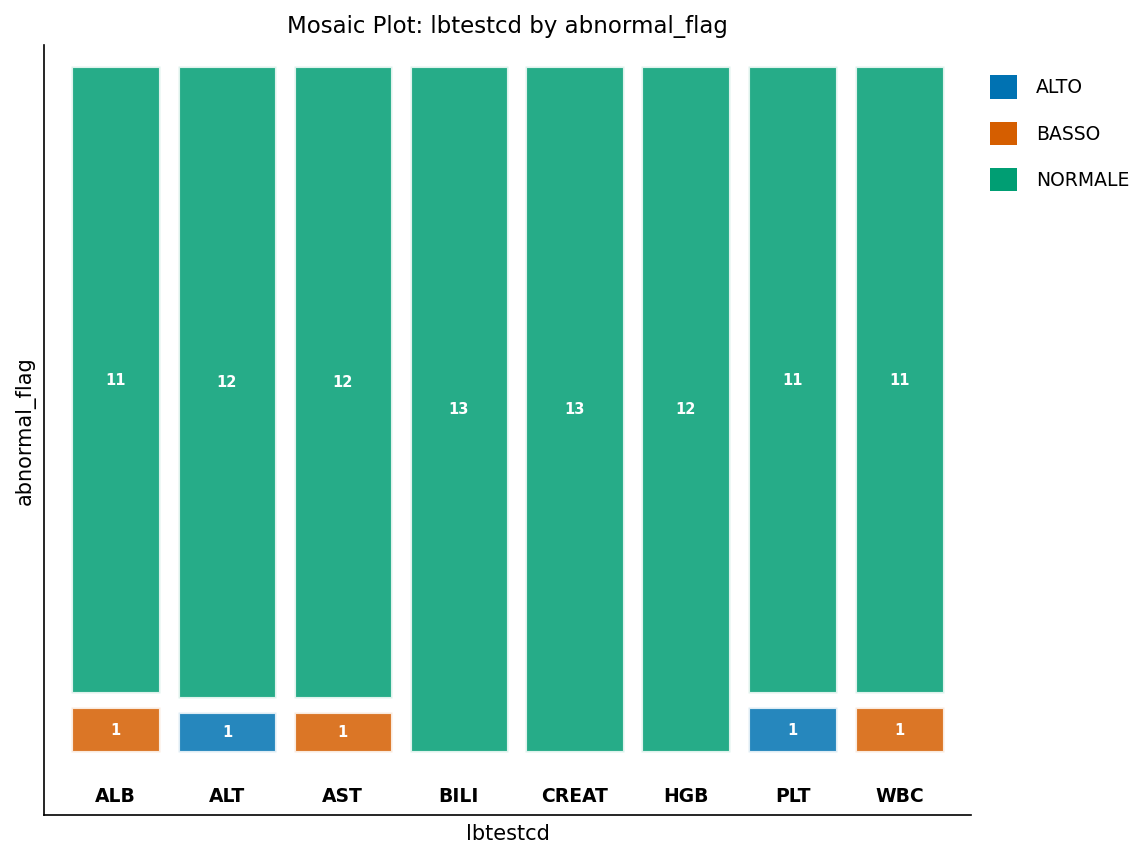

In [7]:
/* --------------------------------------------------------
   Segnala i risultati fuori dall'intervallo di riferimento
   -------------------------------------------------------- */
DATI work.lab_flagged;
    IMPOSTARE work.lab_import;
    LUNGHEZZA abnormal_flag $10;
    low_ref = INGRESSO(lbornrlo, best.);
    high_ref = INGRESSO(lbornrhi, best.);
    SE_COND lbstresn < low_ref ALLORA abnormal_flag = 'BASSO';
    ALTRIMENTI SE_COND lbstresn > high_ref ALLORA abnormal_flag = 'ALTO';
    ALTRIMENTI abnormal_flag = 'NORMALE';
ESEGUIRE;

PROCEDURA FREQUENZE DATI=work.lab_flagged;
    TABLES lbtestcd * abnormal_flag / nocum nopercent;
    ETICHETTA lbtestcd="Codice Analita" abnormal_flag="Segnale Anomalia";
ESEGUIRE;


---

### Interpretazione

PROC IMPORT ha acquisito i record di laboratorio centrale dall'estratto CSV. In questo ambiente sandbox jenner gira in modalità non licenziata, che limita l'esecuzione a 100 osservazioni anziché alle 5.000 dell'estratto completo — un vincolo dell'ambiente di esecuzione, non un effetto della localizzazione. GUESSINGROWS=MAX ha comunque permesso al lettore di scandire ogni riga disponibile prima di fissare i tipi di colonna. PROC CONTENTS conferma 13 variabili; su questo campione ridotto la variabile data LBDTC è stata inferita come numerica anziché carattere (6 numeriche, 7 carattere) — anche questo è un effetto del campione da 100 righe, non della traduzione. L'analisi dell'intervallo di riferimento su questo campione dà una media di ALT di 35,3 U/L (DS 13,4) e una media di AST di 22,2 U/L (DS 9,7), entrambe centrate entro i limiti normali; il box plot mostra distribuzioni dell'ALT comparabili tra le visite, con solo pochi valori che superano il limite superiore della norma di 56 U/L. Su questo campione di 100 risultati, 5 (5,0%) ricadono fuori dal proprio intervallo di riferimento, con tassi per analita che vanno dallo 0% (BILI, CREAT, HGB) a circa l'8,3% (ALB, PLT, WBC), data la scarsa numerosità per analita in questo campione ridotto. Queste statistiche riassuntive per analita e per visita restano l'elemento che un medical monitor esaminerebbe per individuare segnali di laboratorio una volta che i dati reali dello studio, sull'intero campione di 5.000 righe, sostituiranno l'estratto generato.


---

In [8]:
/* --------------------------------------------------------
   Esporta il riepilogo dell'intervallo di riferimento di
   laboratorio per il report del medical monitor
   -------------------------------------------------------- */
PROCEDURA EXPORT DATI=work.lab_range_summary
    OUTFILE='lab_reference_range_summary.csv'
    DBMS=csv REPLACE;
ESEGUIRE;



NOTE: PROC EXPORT data=work.lab_range_summary outfile=lab_reference_range_summary.csv

NOTE: Exported 54 rows to lab_reference_range_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>